# **Online Retail Transaction Analysis**
**Source:** [Kaggle — Online Retail Transaction Data](https://www.kaggle.com/datasets/thedevastator/online-retail-transaction-data)

**Project Objectives:**

1. **Transaction Health & Revenue Integrity:** To classify and separate genuine sales from non-revenue transactions (returns, damage, adjustments), establishing a clean analytical foundation.

2. **Customer Segmentation via RFM:** To rank and profile every customer using Recency, Frequency, and Monetary scoring — enabling targeted marketing and retention strategy.

3. **Market Basket Analysis:** To uncover product co-purchase patterns using association rule mining, supporting cross-selling and bundling recommendations.

4. **Operational Pattern Analysis:** To identify peak hours, busiest days, and seasonal revenue trends to inform staffing, campaign timing, and inventory planning.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### **1. Data Loading & Initial Inspection**
We begin by loading the raw dataset and performing an initial structural check — reviewing data types, column names, missing values, and duplicates before any transformation is applied.

In [ ]:
import pandas as pd

df_raw = pd.read_excel('Online Retail.xlsx')
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df_master = df_raw.copy()
df_master['InvoiceDate'] = pd.to_datetime(df_master['InvoiceDate'])

In [ ]:
df_master['CustomerID'] = df_master['CustomerID'].astype('category')
df_master['Country'] = df_master['Country'].astype('category')

In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  category      
 7   Country      541909 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 26.5+ MB


In [ ]:
df_master['Description'].value_counts().tail(30)

,count
Description,
20713,1
LARGE HEART FLOWERS HOOK,1
PINK DOLLY HAIR CLIPS,1
dotcom sales,1
wrongly marked,1
SET 10 CARDS CHRISTMAS BAUBLE 16954,1
SET 10 CARDS TRIANGLE ICONS 17220,1
check?,1
rusty thrown away,1


In [ ]:
df_master.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df_master[df_master['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [ ]:
df_master[df_master['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [ ]:
#persentase missing value tiap kolom
(df_master.isna().mean() * 100).round(2)

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.27
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,24.93
Country,0.00


The missing value audit reveals two columns with gaps: `CustomerID` (~25%) and `Description` (~0.27%). Rather than dropping these rows — which would eliminate a significant portion of transactions — we apply targeted imputation strategies:
- `CustomerID` nulls are filled with `'Unknown'` to preserve transaction records for aggregate analysis while keeping them out of customer-level RFM modeling.
- `Description` nulls and entries containing `'?'` are standardized to `'Unknown'` to prevent downstream errors in product analysis.

In [ ]:
cek_kembar = df_master[df_master.duplicated(keep=False)].sort_values(by=['InvoiceNo', 'StockCode'])

display(cek_kembar.head())
df_master=df_master.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom


In [ ]:
df_master.duplicated().sum()

np.int64(0)

Duplicate check returns zero remaining duplicates after removal — confirming the dataset is structurally clean and ready for classification logic.

In [ ]:
df_master['CustomerID'] = (
    df_master['CustomerID']
    .cat.add_categories(['Unknown'])
    .fillna('Unknown')
)

In [ ]:
df_master['Description'] = df_master['Description'].fillna('Unknown')
df_master['Description'] = df_master['Description'].astype(str).str.strip().str.title()

df_master['Description'].value_counts().tail()

,count
Description,
Dotcomstock,1
Set 10 Cards 3 Wise Men 17107,1
Missing?,1
Flower Shop Design Mug,1
Check?,1


In [ ]:
(df_master['Quantity'] < 0).sum()     # retur

np.int64(10587)

In [ ]:
(df_master['UnitPrice'] < 0).sum()   # harga aneh

np.int64(2)

In [ ]:
df_master[df_master['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust Bad Debt,1,2011-08-12 14:51:00,-11062.06,Unknown,United Kingdom
299984,A563187,B,Adjust Bad Debt,1,2011-08-12 14:52:00,-11062.06,Unknown,United Kingdom


In [ ]:
logic_check = df_master.assign(
    q_sign = df_master['Quantity'].apply(
        lambda x: 'pos' if x > 0 else 'neg' if x < 0 else 'zero'
    ),
    p_sign = df_master['UnitPrice'].apply(
        lambda x: 'pos' if x > 0 else 'neg' if x < 0 else 'zero'
    )
)

logic_check.groupby(['q_sign', 'p_sign']).size()


q_sign  p_sign
neg     pos         9251
        zero        1336
pos     neg            2
        pos       524878
        zero        1174
dtype: int64

In [ ]:
# 1. Hitung pakai jalur ninja
persentase_ninja = (logic_check[['q_sign', 'p_sign']].value_counts(normalize=True) * 100).round(2)

# 2. Ubah wujud jadi tabel (DataFrame)
tabel_flat = persentase_ninja.reset_index(name='Persentase')

# 3. Dandanin kolom Persentase pakai '%'
tabel_flat['Persentase'] = tabel_flat['Persentase'].astype(str) + '%'

# 4. Pamerin pakai display() biar bentuk tabelnya keluar!
display(tabel_flat)

,q_sign,p_sign,Persentase
0,pos,pos,97.81%
1,neg,pos,1.72%
2,neg,zero,0.25%
3,pos,zero,0.22%
4,pos,neg,0.0%


### **2. Transaction Classification: Separating Revenue from Operational Leakage**
A critical prerequisite before any analysis is understanding what each row in the dataset actually represents. Not all transactions generate revenue. By applying a rule-based classification on `Quantity` sign, `UnitPrice` sign, and `InvoiceNo` prefix, every record is mapped into one of five distinct business categories:

1. **Sales (524,878 rows):** The core revenue engine. Clean, positive-value transactions that form the foundation for all downstream RFM modeling and Market Basket Analysis.
2. **Returns (9,251 rows):** Customers returning goods — a silent profit drain. The QC and packing teams should investigate the most frequently returned products to reduce this leakage.
3. **Damage / Write-off (1,336 rows):** Goods destroyed, expired, or disposed of without generating any revenue. An audit of warehouse SOPs is recommended.
4. **Free Items / Promotions (1,174 rows):** Goods distributed as samples or bonuses. A follow-up analysis is needed to confirm whether this marketing spend produces measurable retention lift.
5. **Adjustment / System Anomaly (2 rows):** Records with contradictory logic — safe to exclude from all downstream analysis.

In [ ]:
df_master[df_master['UnitPrice'] == 0]['Description'].value_counts().head()

,count
Description,
Unknown,1454
Check,162
Damaged,58
?,47
Damages,46


In [ ]:
# Cari baris yang kolom Description-nya mengandung tanda tanya '?'
baris_tanya = df_master[df_master['Description'].str.contains('?', regex=False, na=False)]
display(baris_tanya.tail(10))

print("Total baris aneh:", len(baris_tanya))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
489198,577959,85107,Check?,374,2011-11-22 12:11:00,0.0,Unknown,United Kingdom
493686,578245,22568,?? Missing,-170,2011-11-23 12:37:00,0.0,Unknown,United Kingdom
497819,578476,72807B,????Missing,-124,2011-11-24 12:45:00,0.0,Unknown,United Kingdom
497820,578477,72807A,???Missing,-224,2011-11-24 12:45:00,0.0,Unknown,United Kingdom
497821,578478,72807C,???Missing,-428,2011-11-24 12:45:00,0.0,Unknown,United Kingdom
514649,579734,84859C,Wet?,-153,2011-11-30 14:25:00,0.0,Unknown,United Kingdom
514735,579742,85204,Lost??,-1131,2011-11-30 14:34:00,0.0,Unknown,United Kingdom
524370,580547,21201,???,-390,2011-12-05 09:29:00,0.0,Unknown,United Kingdom
535324,581201,22217,Damages?,-155,2011-12-07 18:30:00,0.0,Unknown,United Kingdom
535327,581204,85104,????Damages????,-355,2011-12-07 18:32:00,0.0,Unknown,United Kingdom


Total baris aneh: 82


In [ ]:
df_master['Quantity'].describe()

,Quantity
count,536641.000000
mean,9.620029
std,219.130156
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


The descriptive statistics reveal a clear structural duality in the customer base:
- **B2C Dominance:** The median purchase is just **3 units**, with 75% of transactions involving 10 items or fewer — confirming that the overwhelming majority of customers are casual retail buyers.
- **Wholesale Segment (B2B):** The extreme gap between the 75th percentile (10) and maximum (80,995) signals the presence of a small number of bulk buyers operating at a fundamentally different scale.
- **Symmetric Extremes:** The maximum (+80,995) and minimum (-80,995) are mirror images — representing a massive wholesale order and its full cancellation. These must be treated as outliers before modeling.

### **3. Quantity Distribution: Identifying the B2C vs. B2B Split**
Before modeling, we examine the statistical distribution of the `Quantity` column to understand the purchasing behavior profile of this business — and to identify extreme values that would distort downstream analysis.

In [ ]:
df_master['UnitPrice'].describe()

,UnitPrice
count,536641.000000
mean,4.632656
std,97.233118
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


Three distinct anomaly types emerge from the `UnitPrice` distribution:
- **Mass-Market Profile:** A median of 2.08 and 75th percentile of 4.13 confirms this is a low-cost, high-volume retail operation — consistent with a gift or souvenir business model.
- **Negative Prices:** A minimum of -11,062.06 is logically impossible for a physical product. These represent accounting corrections (bad debt write-offs, invoice reversals) that must be excluded from revenue calculations.
- **Administrative Cost Codes:** A maximum of 38,970.00 is highly atypical for a retail SKU. These are likely non-product transaction codes (bank charges, platform fees, or manual shipping entries) that would distort any pricing or revenue model if retained.

### **4. Unit Price Distribution: Detecting Accounting Anomalies**
We repeat the same distributional inspection on `UnitPrice` to surface any pricing anomalies that must be separated from genuine product transactions before analysis.

In [ ]:
df_master['transaction_type'] = 'unknown'

# 1. Cancellation (paling atas)
mask_invoice = df_master['InvoiceNo'].notna()
df_master.loc[
    mask_invoice & df_master['InvoiceNo'].str.startswith('C'),
    'transaction_type'
] = 'cancellation'

# 2. Return
df_master.loc[
    (df_master['transaction_type'] == 'unknown') &
    (df_master['Quantity'] < 0) &
    (df_master['UnitPrice'] > 0),
    'transaction_type'
] = 'return'

# 3. Adjustment / bad debt
df_master.loc[
    (df_master['transaction_type'] == 'unknown') &
    (df_master['UnitPrice'] < 0),
    'transaction_type'
] = 'adjustment'

# 4. Damage / write-off
df_master.loc[
    (df_master['transaction_type'] == 'unknown') &
    (df_master['Quantity'] < 0) &
    (df_master['UnitPrice'] == 0),
    'transaction_type'
] = 'damage_writeoff'

# 5. Free item
df_master.loc[
    (df_master['transaction_type'] == 'unknown') &
    (df_master['Quantity'] > 0) &
    (df_master['UnitPrice'] == 0),
    'transaction_type'
] = 'free_item'

# 6. Sale
df_master.loc[
    (df_master['transaction_type'] == 'unknown') &
    (df_master['Quantity'] > 0) &
    (df_master['UnitPrice'] > 0),
    'transaction_type'
] = 'sale'

# 7. Sisa
df_master.loc[
    df_master['transaction_type'] == 'unknown',
    'transaction_type'
] = 'anomaly'


In [ ]:
df_master

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,sale
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,sale
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,sale
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France,sale
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France,sale
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France,sale


In [ ]:
df_master['transaction_type'].value_counts()

,count
transaction_type,
sale,524878
cancellation,9251
damage_writeoff,1336
free_item,1174
adjustment,2


The classification confirms that **87%+ of all records are genuine sales** — validating that the business is fundamentally healthy. However, the 9,251 returns and 1,336 damage/write-off entries represent meaningful operational leakage that warrants further investigation by the QC, packing, and warehouse teams.

In [ ]:
invoice_check = df_master.groupby('InvoiceNo').agg(
    total_qty = ('Quantity', 'sum'),
    total_value = ('UnitPrice', 'sum'),
    types = ('transaction_type', 'nunique')
)

invoice_check.sort_values('types', ascending=False).head()

,total_qty,total_value,types
InvoiceNo,,,
546406,508,848.86,2
574252,95,46.23,2
571035,352,248.10,2
540372,2650,400.71,2
561669,675,45.40,2


In [ ]:
# Versi ini akan menampilkan LIST nama tipe transaksinya
invoice_check_list = df_master.groupby('InvoiceNo').agg(
    total_qty = ('Quantity', 'sum'),
    list_types = ('transaction_type', 'unique') # Menggunakan unique, bukan nunique
)

# Tampilkan invoice yang punya lebih dari 1 tipe
invoice_check_list[invoice_check_list['list_types'].map(len) > 1].head()

,total_qty,list_types
InvoiceNo,,
537197,80,"[sale, free_item]"
537534,114,"[free_item, sale]"
537640,2201,"[sale, free_item]"
538071,1643,"[sale, free_item]"
538877,2153,"[sale, free_item]"


In [ ]:
# Ekstrak elemen waktu
df_master['MonthYear'] = df_master['InvoiceDate'].dt.to_period('M') # Cuma ambil Bulan-Tahun
df_master['DayOfWeek'] = df_master['InvoiceDate'].dt.day_name() # Biar keluar nama harinya (Monday, Tuesday, dll)
df_master['Hour'] = df_master['InvoiceDate'].dt.hour

display(df_master[['InvoiceDate', 'MonthYear', 'DayOfWeek', 'Hour']].tail())

,InvoiceDate,MonthYear,DayOfWeek,Hour
541904,2011-12-09 12:50:00,2011-12,Friday,12
541905,2011-12-09 12:50:00,2011-12,Friday,12
541906,2011-12-09 12:50:00,2011-12,Friday,12
541907,2011-12-09 12:50:00,2011-12,Friday,12
541908,2011-12-09 12:50:00,2011-12,Friday,12


In [ ]:
# Menghitung persentase transaksi per negara
country_prop = df_master['Country'].value_counts(normalize=True) * 100

print("Top 5 Negara Penyumbang Transaksi Terbesar (%):")
print(country_prop.head())

Top 5 Negara Penyumbang Transaksi Terbesar (%):
Country
United Kingdom    91.364618
Germany            1.766544
France             1.591567
EIRE               1.525042
Spain              0.471078
Name: proportion, dtype: float64


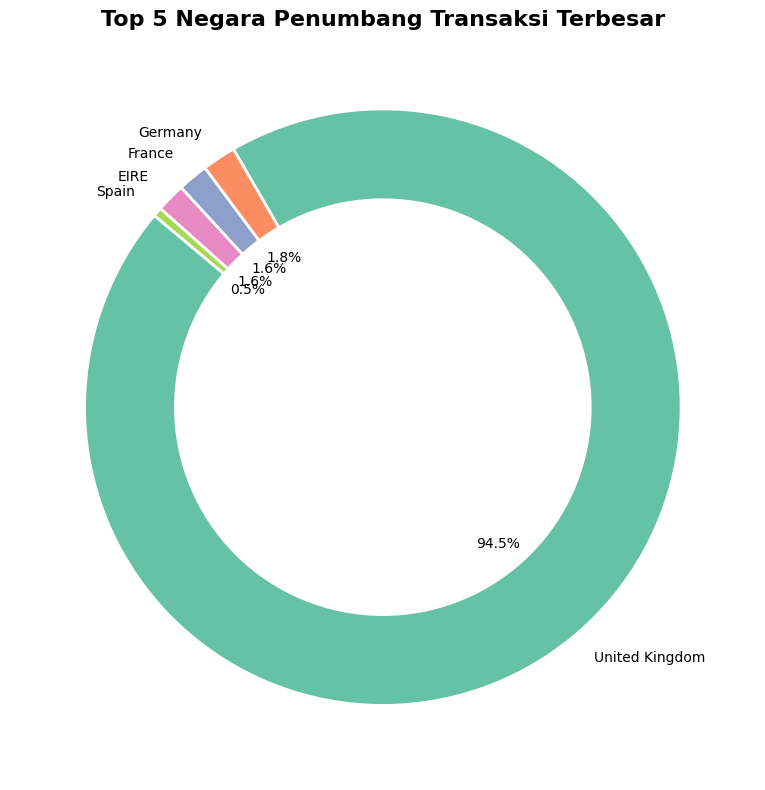

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kita ambil Top 5 negara aja biar grafiknya nggak keramean
top_5_countries = country_prop.head()

# 2. Bikin Donut Chart yang estetik
plt.figure(figsize=(8, 8))
plt.pie(
    top_5_countries,
    labels=top_5_countries.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 3. Trik bikin lingkaran putih di tengah (biar jadi Donut, bukan Pie biasa)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 5 Negara Penumbang Transaksi Terbesar', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()


### **5. Product-Level Analysis: Revenue Drivers & Operational Waste**
With transaction classification complete, we shift focus to product-level performance — computing revenue per product, identifying the top earners by both quantity and monetary value, and isolating operational waste (postage entries, zero-price items) that must be excluded before customer-level modeling.

In [ ]:
# df_product is a purpose-built dataset for product analysis, MBA, and RFM.
# It starts from df_master but applies stricter filtering to remove noise
# that would distort product-level insights.
#
# Why filter Description != 'Unknown' here?
# Rows with unknown descriptions cannot be meaningfully included in
# product ranking or market basket analysis — we cannot know what product
# was actually purchased. Keeping them would create a phantom "Unknown"
# entry that dominates product rankings.
#
# All subsequent cleaning steps (POSTAGE removal, outlier removal,
# CustomerID filtering) are applied only to df_product — df_master
# remains intact as the source of truth for revenue and operational reporting.

df_product = df_master[
    df_master['Description'] != 'Unknown'
].copy()

In [ ]:
df_product

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,sale,2010-12,Wednesday,8
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,sale,2010-12,Wednesday,8
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,sale,2011-12,Friday,12
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France,sale,2011-12,Friday,12
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12


In [ ]:
df_master[df_master['transaction_type'] == 'damage_writeoff']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour
2406,536589,21777,Unknown,-10,2010-12-01 16:50:00,0.0,Unknown,United Kingdom,damage_writeoff,2010-12,Wednesday,16
4347,536764,84952C,Unknown,-38,2010-12-02 14:42:00,0.0,Unknown,United Kingdom,damage_writeoff,2010-12,Thursday,14
7188,536996,22712,Unknown,-20,2010-12-03 15:30:00,0.0,Unknown,United Kingdom,damage_writeoff,2010-12,Friday,15
7189,536997,22028,Unknown,-20,2010-12-03 15:30:00,0.0,Unknown,United Kingdom,damage_writeoff,2010-12,Friday,15
7190,536998,85067,Unknown,-6,2010-12-03 15:30:00,0.0,Unknown,United Kingdom,damage_writeoff,2010-12,Friday,15
...,...,...,...,...,...,...,...,...,...,...,...,...
535333,581210,23395,Check,-26,2011-12-07 18:36:00,0.0,Unknown,United Kingdom,damage_writeoff,2011-12,Wednesday,18
535335,581212,22578,Lost,-1050,2011-12-07 18:38:00,0.0,Unknown,United Kingdom,damage_writeoff,2011-12,Wednesday,18
535336,581213,22576,Check,-30,2011-12-07 18:38:00,0.0,Unknown,United Kingdom,damage_writeoff,2011-12,Wednesday,18
536908,581226,23090,Missing,-338,2011-12-08 09:56:00,0.0,Unknown,United Kingdom,damage_writeoff,2011-12,Thursday,9


### **6. Outlier Removal: Isolating the True B2C Signal**
Before proceeding to RFM modeling and Market Basket Analysis, extreme `Quantity` outliers must be removed. We apply a conservative **IQR × 3 threshold** — the most appropriate choice here because:
- Standard IQR × 1.5 would be too aggressive, removing legitimate large orders.
- IQR × 3 specifically targets *extreme* outliers (the wholesale giants and mass cancellations identified earlier) while preserving the full B2C distribution.

This step is not optional. Training a recommendation algorithm on outlier-contaminated data would cause it to optimize for the behavior of a handful of bulk buyers — not the 4,000+ retail customers who represent the actual business.

In [ ]:
# Bikin kolom 'Revenue' (Pendapatan per baris transaksi)
df_product['Revenue'] = df_product['Quantity'] * df_product['UnitPrice']

# -- KLASEMEN 1: Top 10 Produk Paling Laris (Kuantitas) --
top_qty = df_product.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# -- KLASEMEN 2: Top 10 Produk Paling Cuan (Revenue) --
top_revenue = df_product.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print("TOP 10 BARANG PALING LARIS (Berdasarkan Kuantitas):")
print(top_qty)
print("\n" + "="*50 + "\n")
print("TOP 10 BARANG PALING CUAN (Berdasarkan Total Revenue):")
print(top_revenue)

TOP 10 BARANG PALING LARIS (Berdasarkan Kuantitas):
Description
World War 2 Gliders Asstd Designs     53751
Jumbo Bag Red Retrospot               47260
Popcorn Holder                        36322
Assorted Colour Bird Ornament         36282
Pack Of 72 Retrospot Cake Cases       36016
White Hanging Heart T-Light Holder    35298
Rabbit Night Light                    30631
Mini Paint Set Vintage                26437
Pack Of 12 London Tissues             26299
Pack Of 60 Pink Paisley Cake Cases    24719
Name: Quantity, dtype: int64


TOP 10 BARANG PALING CUAN (Berdasarkan Total Revenue):
Description
Dotcom Postage                        206245.48
Regency Cakestand 3 Tier              164459.49
White Hanging Heart T-Light Holder     99612.42
Party Bunting                          98243.88
Jumbo Bag Red Retrospot                92175.79
Rabbit Night Light                     66661.63
Postage                                66230.64
Paper Chain Kit 50'S Christmas         63715.24
Assorted Colou

The top-revenue products are not necessarily the top-quantity products — a critical distinction for inventory and pricing strategy. High-quantity items (e.g., White Hanging Heart) may be low-margin volume sellers, while high-revenue items (e.g., Regency Cakestand) represent premium products that punch above their unit count.

Postage and zero-price entries are identified and removed at this stage — these are administrative entries, not physical products, and must be excluded to ensure RFM and association rule mining reflect genuine purchasing behavior.

In [ ]:
# Mencari semua baris yang kolom Description-nya mengandung kata 'POSTAGE'
# case=False biar dia nggak rewel urusan huruf besar/kecil
# na=False biar kodenya nggak ngambek/error kalau nemu baris yang description-nya kosong
siluman_postage = df_product[df_product['Description'].str.contains('POSTAGE', case=False, na=False)]

# Tampilin 5 atau 10 baris pertamanya aja biar layarmu nggak penuh
print("Penampakan asli baris siluman:")
display(siluman_postage.head(10))

# Kalau mau iseng ngecek seberapa banyak nyamuk ongkir ini menuhin datamu:
print(f"\nTotal baris yang isinya transaksi ongkir: {len(siluman_postage)} baris!")

Penampakan asli baris siluman:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour,Revenue
45,536370,POST,Postage,3,2010-12-01 08:45:00,18.00,12583.0,France,sale,2010-12,Wednesday,8,54.00
386,536403,POST,Postage,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands,sale,2010-12,Wednesday,11,15.00
1123,536527,POST,Postage,1,2010-12-01 13:04:00,18.00,12662.0,Germany,sale,2010-12,Wednesday,13,18.00
1814,536544,DOT,Dotcom Postage,1,2010-12-01 14:32:00,569.77,Unknown,United Kingdom,sale,2010-12,Wednesday,14,569.77
3041,536592,DOT,Dotcom Postage,1,2010-12-01 17:06:00,607.49,Unknown,United Kingdom,sale,2010-12,Wednesday,17,607.49
5073,536840,POST,Postage,1,2010-12-02 18:27:00,18.00,12738.0,Germany,sale,2010-12,Thursday,18,18.00
5258,536852,POST,Postage,1,2010-12-03 09:51:00,18.00,12686.0,France,sale,2010-12,Friday,9,18.00
5325,536858,POST,Postage,2,2010-12-03 10:36:00,40.00,13520.0,Switzerland,sale,2010-12,Friday,10,80.00
5369,536861,POST,Postage,3,2010-12-03 10:44:00,18.00,12427.0,Germany,sale,2010-12,Friday,10,54.00
5450,536862,DOT,Dotcom Postage,1,2010-12-03 11:13:00,254.43,Unknown,United Kingdom,sale,2010-12,Friday,11,254.43



Total baris yang isinya transaksi ongkir: 1961 baris!


In [ ]:
# Step 1: Remove POSTAGE entries
# POSTAGE rows represent shipping fees billed as separate line items.
# Including them in product analysis would create false association rules:
# "customers who buy Cakestand also buy POSTAGE" — not a meaningful insight.
df_product = df_product[~df_product['Description'].str.contains('POSTAGE', case=False, na=False)]

# Step 2: Remove UnitPrice <= 0
# Zero or negative prices are not genuine product transactions:
# - Price = 0: free samples or marketing giveaways
# - Price < 0: accounting corrections (bad debt write-offs, credit notes)
# Including these would distort the Monetary component of RFM scoring,
# potentially making free-item recipients appear as high-value customers.
df_product = df_product[df_product['UnitPrice'] > 0]

# Step 3: Remove unknown CustomerID
# RFM and MBA require traceable customer identities.
# Rows with CustomerID = 'Unknown' cannot be attributed to a specific customer —
# aggregating them would treat thousands of anonymous transactions as
# belonging to one "mega-customer", producing meaningless RFM scores
# and distorted association rules.
df_product = df_product[df_product['CustomerID'] != 'Unknown']

# Step 4: Remove negative Quantity (returns/cancellations)
# For product ranking and MBA, we only want genuine purchase transactions.
# Returns would subtract from product revenue and create negative basket entries.
df_product = df_product[df_product['Quantity'] > 0]

print(f"df_master rows: {len(df_master):,}")
print(f"df_product rows after cleaning: {len(df_product):,}")
print(f"Rows removed: {len(df_master) - len(df_product):,}")

Data awal kita ada: 536641 baris.
Data Product bersih kita sisa: 523046 baris!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour,Revenue
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,sale,2010-12,Wednesday,8,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,sale,2010-12,Wednesday,8,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34


In [ ]:
# Outlier Detection: IQR × 3 Method
# We compute the Interquartile Range (IQR) on the Quantity column
# to identify extreme wholesale orders that would distort B2C analysis.
#
# Why IQR × 3 instead of the standard IQR × 1.5?
# - IQR × 1.5 (Tukey's standard) is designed for normally distributed data.
#   Applied here, it would flag legitimate large retail orders as outliers.
# - IQR × 3 targets only "extreme" outliers — the wholesale giants
#   (80,000+ units) that represent a fundamentally different business
#   segment from the 4,000+ B2C retail customers we want to analyze.
#
# Why remove wholesale outliers for product analysis?
# FP-Growth and RFM are designed to surface patterns across many customers.
# A single wholesale buyer purchasing 80,000 units of product X and 74,000
# units of product Y would make those products appear as top co-purchase
# pairs — but this reflects ONE buyer's behavior, not the purchasing
# patterns of the retail customer base.

Q1 = df_product['Quantity'].quantile(0.25)
Q3 = df_product['Quantity'].quantile(0.75)
IQR = Q3 - Q1

batas_atas = Q3 + (3 * IQR)

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper bound (IQR × 3): {batas_atas:.0f} units")

anomali_qty = df_product[df_product['Quantity'] > batas_atas]
print(f"
Extreme outlier rows identified: {len(anomali_qty):,}")
print(f"These represent wholesale orders at a different scale from B2C retail.")
display(anomali_qty.sort_values(by='Quantity', ascending=False).head(5))

Secara statistik, batas wajar maksimal orang beli barang adalah: 45.0 pieces.
Terdapat 19167 baris transaksi ANOMALI EKSTREM!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour,Revenue
540421,581483,23843,"Paper Craft , Little Birdie",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,sale,2011-12,Friday,9,168469.60
61619,541431,23166,Medium Ceramic Top Storage Jar,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,sale,2011-01,Tuesday,10,77183.60
421632,573008,84077,World War 2 Gliders Asstd Designs,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,sale,2011-10,Thursday,12,1008.00
206121,554868,22197,Small Popcorn Holder,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,sale,2011-05,Friday,10,3096.00
97432,544612,22053,Empire Design Rosette,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,sale,2011-02,Tuesday,10,3202.92
270885,560599,18007,Essential Balm 3.5G Tin In Envelope,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,sale,2011-07,Tuesday,17,191.16
52711,540815,21108,Fairy Cake Flannel Assorted Colour,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,sale,2011-01,Tuesday,12,6539.40
160546,550461,21108,Fairy Cake Flannel Assorted Colour,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,sale,2011-04,Monday,13,6539.40
433788,573995,16014,Small Chinese Style Scissor,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom,sale,2011-11,Wednesday,11,960.00
4945,536830,84077,World War 2 Gliders Asstd Designs,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom,sale,2010-12,Thursday,17,518.40


In [ ]:
# Apply the upper bound filter
# Only positive outliers are removed here.
# Negative extreme values (wholesale returns) have already been removed
# in the previous step (Quantity > 0 filter), so no lower bound is needed.
#
# Note: We store the pre-cleaning snapshot BEFORE removing outliers
# to enable a before/after comparison in the next cell.
df_product_before = df_product.copy()  # Snapshot for comparison visualization

df_product = df_product[df_product['Quantity'] <= batas_atas]

print(f"Rows before outlier removal: {len(df_product_before):,}")
print(f"Rows after outlier removal: {len(df_product):,}")
print(f"Outlier rows removed: {len(df_product_before) - len(df_product):,}")
print(f"\nNew Quantity statistics after cleaning:")
print(df_product['Quantity'].describe().round(2))

Data setelah di-ruqyah dari anomali ekstrem: 503879 baris. Suci bersih!


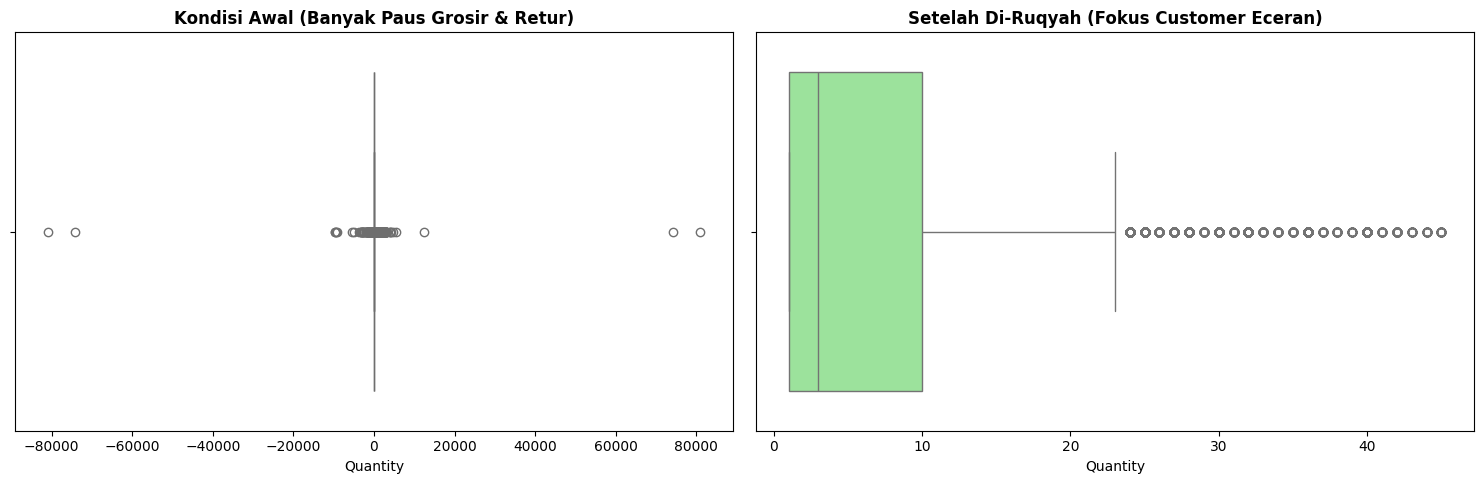

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before vs After comparison using df_product_before (pre-outlier-removal snapshot)
# This is an apple-to-apple comparison — both dataframes have the same
# cleaning applied EXCEPT for the outlier removal step.
# Using df_master for "before" would not be fair because df_master still
# contains POSTAGE, unknown descriptions, and unknown CustomerIDs.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Left: Before outlier removal
sns.boxplot(x=df_product_before['Quantity'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before Outlier Removal\n(Wholesale extremes dominate scale)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Quantity per Transaction')

# Right: After outlier removal
sns.boxplot(x=df_product['Quantity'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal (IQR × 3)\n(True B2C distribution visible)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Quantity per Transaction')

plt.suptitle('Distribution Comparison: Quantity Before vs After Outlier Removal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **6b. Distribution Comparison: Before vs. After Outlier Removal**
The side-by-side boxplot validates the outlier removal decision:

**Before (Left) — Scale Dominated by Extremes:**
The interquartile box, which should represent the middle 50% of all transactions, is compressed into a near-invisible line at the bottom. The ±80,000 extremes dictate the entire scale, making the distribution of the core customer base completely unreadable.

**After (Right) — The True B2C Profile:**
With extreme outliers removed, the actual purchasing pattern becomes clearly visible: the majority of customers buy between **1 and 10 items** per transaction, with a median of **3 items**. This clean distribution confirms the B2C hypothesis and is now a reliable input for quantile-based RFM scoring.

### **7. RFM Analysis: Building a Customer Behavioral Score**
RFM (Recency, Frequency, Monetary) is a rule-based segmentation framework that evaluates every customer on three behavioral dimensions simultaneously:
- **Recency (R):** Days since last purchase. More recent = higher score.
- **Frequency (F):** Number of unique invoices. More frequent = higher score.
- **Monetary (M):** Total revenue generated. Higher spend = higher score.

Each dimension is scored 1–4. We deliberately use **quantile-based ranking (pd.qcut)** rather than fixed value thresholds — the right methodological choice for this data, as justified by the skewed distributions observed earlier.

In [ ]:
import datetime as dt

# Reference date: the day AFTER the last transaction in df_master (not df_product).
# Why df_master and not df_product?
# df_product has been filtered — its max date may differ from the true
# last transaction date in the full dataset. Using df_master ensures
# all customers are evaluated against the same consistent reference point.
#
# Why add 1 day?
# A customer whose last purchase was on the max date would have Recency = 0,
# which cannot be scored by pd.qcut. Adding 1 day ensures minimum Recency = 1.

tanggal_patokan = df_master['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Reference date for Recency calculation: {tanggal_patokan.date()}")

# RFM Aggregation
# - Recency: days since last purchase (lower = more recent = better)
# - Frequency: number of UNIQUE invoices (not row count)
#   Why InvoiceNo nunique and not InvoiceDate count?
#   One invoice can contain many products (many rows). Counting rows would
#   make a customer who buys 10 products in 1 visit appear as Frequency=10,
#   when the correct answer is Frequency=1 (one shopping trip).
# - Monetary: total spend across all transactions

rfm = df_product.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (tanggal_patokan - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),   # ← unique shopping trips, not rows
    Monetary=('Revenue', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print(f"Customers with at least 1 valid transaction: {len(rfm):,}")
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,NaN,0,0.00
1,12347.0,2.0,7,3974.48
2,12348.0,249.0,3,90.20
3,12349.0,19.0,1,1457.55
4,12350.0,310.0,1,294.40


The RFM table assigns three raw metrics to every CustomerID: days since last purchase (Recency), number of unique transactions (Frequency), and total spend (Monetary). These raw values are then converted into comparable 1–4 scores in the next step.

In [ ]:
# Remove customers with Frequency = 0
# After cleaning, some CustomerIDs may have zero valid transactions
# (their only transactions were returns or outliers that were removed).
# These cannot be meaningfully scored — exclude them from RFM.
rfm = rfm[rfm['Frequency'] > 0].copy()

# RFM Scoring: 1–4 quantile-based ranks
# Why pd.qcut (quantile-based) instead of pd.cut (fixed intervals)?
# All three RFM metrics are heavily right-skewed:
# - Most customers have low Frequency (1–3 visits)
# - Most customers have low Monetary (small total spend)
# Using fixed intervals (pd.cut) would assign 80-90% of customers
# to the lowest bucket — making the segmentation meaningless.
# pd.qcut distributes customers evenly by population percentile,
# ensuring each score tier represents ~25% of the customer base
# regardless of the underlying distribution shape.

label_1_4 = [1, 2, 3, 4]
label_4_1 = [4, 3, 2, 1]  # Reversed: lower Recency (more recent) = higher score

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=label_4_1)

# Why rank method for Frequency?
# Many customers have identical Frequency values (e.g., hundreds with Frequency=1).
# Standard pd.qcut cannot handle ties at bin edges and raises errors.
# rank(method='first') assigns unique ranks before cutting, resolving ties.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=label_1_4)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=label_1_4)

rfm['RFM_Segment'] = (rfm['R_Score'].astype(str) +
                      rfm['F_Score'].astype(str) +
                      rfm['M_Score'].astype(str))

print(f"RFM scored customers: {len(rfm):,}")
print(f"\nScore distribution:")
print(rfm[['R_Score','F_Score','M_Score']].apply(lambda x: x.value_counts()).T)
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
1,12347.0,2.0,7,3974.48,4,4,4,444
2,12348.0,249.0,3,90.20,1,3,1,131
3,12349.0,19.0,1,1457.55,3,1,4,314
4,12350.0,310.0,1,294.40,1,1,2,112
5,12352.0,36.0,8,2226.04,3,4,4,344


Each customer now has a combined `RFM_Segment` string (e.g., '444' = best possible score across all three dimensions). This segment code acts as a behavioral fingerprint — compressing complex purchasing history into a single, actionable label.

### **7a. Customer Segmentation: Translating RFM Scores into Business Profiles**
The RFM segment codes are mapped to five human-readable customer profiles — each with a distinct behavioral pattern and a corresponding marketing strategy:

- **Champions (444):** Recently active, highly frequent, highest spenders. These customers drive disproportionate revenue and should be the primary focus of loyalty investment. *Strategy: VIP program, early access, exclusive perks.*
- **Loyal Customers:** Frequent buyers with solid monetary value, though not always the most recent. *Strategy: Referral programs, exclusive member offers.*
- **Potential Loyalists:** Recent visitors with low frequency — they tried the store but haven't committed yet. *Strategy: Incentivize the 2nd and 3rd purchase to build habit.*
- **New Customers:** Very recent, but low frequency and spend. *Strategy: Structured onboarding sequence and first-purchase follow-up.*
- **Hibernating / Lost:** Long inactive, low frequency, low spend. *Strategy: Win-back email campaign — or accept churn and reallocate budget to higher-value segments.*

In [ ]:
# Customer Segmentation Function
# Maps RFM score combinations to 5 business-meaningful profiles.
#
# IMPORTANT — Why is "At Risk" checked BEFORE "Loyal Customers"?
# At Risk: R_Score <= 2 AND F_Score >= 3 AND M_Score >= 3
# Loyal:   F_Score >= 3 AND M_Score >= 3 (no R constraint)
# These conditions overlap — an At Risk customer also satisfies the
# Loyal criteria. Checking Loyal first would misclassify At Risk
# customers as Loyal, hiding a critical retention signal.
# The more specific condition (At Risk, which adds the R constraint)
# must always be evaluated before the more general one (Loyal).

def segmen_pelanggan(df):
    # Best customers: high across all three dimensions
    if df['RFM_Segment'] == '444':
        return 'Champions'

    # Previously good customers now becoming inactive — MUST check before Loyal
    # because conditions overlap (both require high F and M)
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'At Risk'

    # Consistently frequent and high-spending customers
    elif df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'Loyal Customers'

    # Recent but infrequent — still building their purchase habit
    elif df['R_Score'] >= 3 and df['F_Score'] <= 2:
        return 'New Customers'

    # Long inactive, low frequency, low spend
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Hibernating / Lost'

    # Catch-all for combinations not covered above
    else:
        return 'Potential Loyalist'

rfm['Customer_Profile'] = rfm.apply(segmen_pelanggan, axis=1)

print("Segment distribution:")
print(rfm['Customer_Profile'].value_counts())
print(f"\nTotal customers segmented: {len(rfm):,}")

KLASEMEN KASTA PELANGGAN
Customer_Profile
Hibernating / Lost    1482
Loyal Customers       1235
New Customers          645
Champions              491
Potential Loyalist     401
Name: count, dtype: int64


The segment distribution reveals the composition of the customer base. A healthy business shows a significant Champions and Loyal Customers group at the top, with Hibernating/Lost not dominating the count — an imbalance toward the bottom segments signals a retention problem that requires immediate strategic attention.

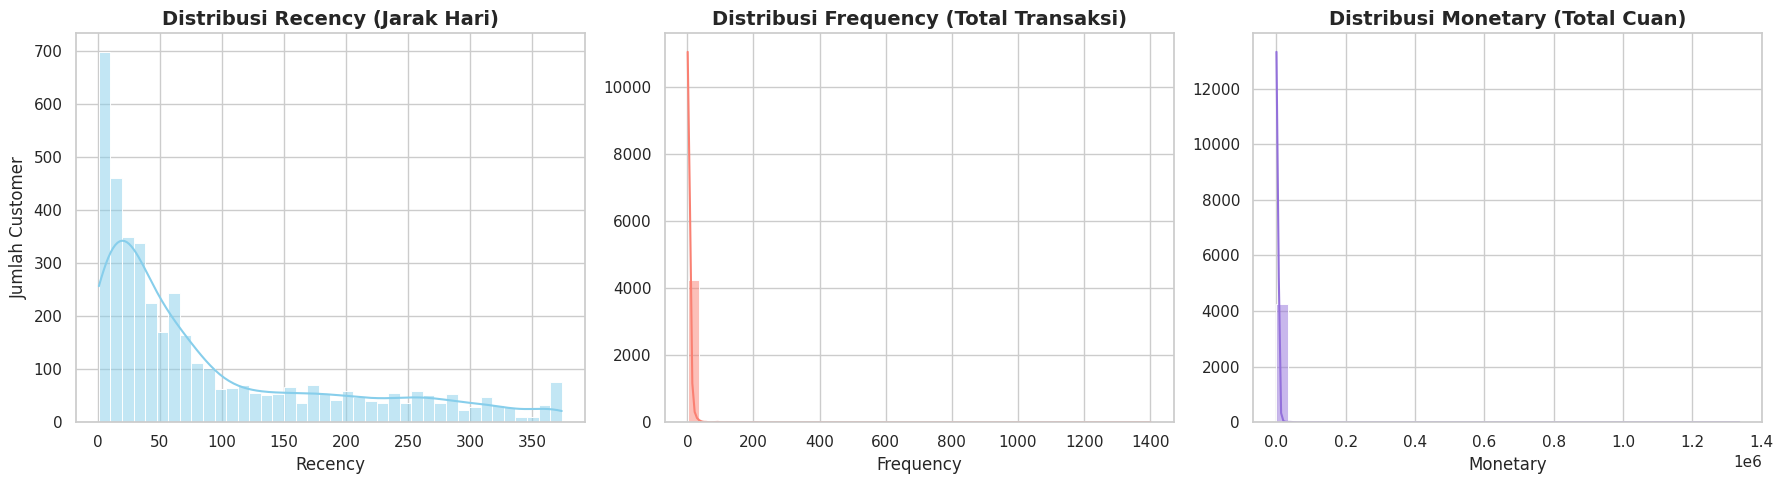

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur canvas buat 3 grafik berjejer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# 1. Distribusi Recency (Makin ke kiri = makin baru mampir)
sns.histplot(rfm['Recency'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Recency (Jarak Hari)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Jumlah Customer')

# 2. Distribusi Frequency (Makin ke kanan = makin sering checkout)
sns.histplot(rfm['Frequency'], bins=40, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Frequency (Total Transaksi)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('')

# 3. Distribusi Monetary (Makin ke kanan = makin sultan)
sns.histplot(rfm['Monetary'], bins=40, kde=True, ax=axes[2], color='mediumpurple')
axes[2].set_title('Distribusi Monetary (Total Cuan)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### **7b. RFM Distribution Analysis: Why Quantile Scoring Is the Correct Approach**
The three histograms above reveal a consistent and critical pattern: **all RFM metrics follow a heavily right-skewed distribution.**

- **Recency:** The majority of customers cluster near 0–50 days, indicating a predominantly active customer base. The long tail toward 350+ days represents a gradually shrinking churned segment — a healthy sign for the business.
- **Frequency & Monetary:** Both exhibit near-identical patterns — a steep concentration of customers on the low end with a long tail extending toward high-value outliers. This confirms the classic Pareto structure: a small number of customers generate a disproportionate share of revenue.

**Methodological Justification for pd.qcut:**
These distributions mathematically disqualify mean-based segmentation. Applying a standard mean-cut to this data would classify approximately 90% of customers into the lowest score tier — rendering the segmentation meaningless. Quantile-based scoring (pd.qcut) distributes customers by population percentile rather than nominal value, ensuring every tier represents a proportional share of the customer base regardless of the skew.

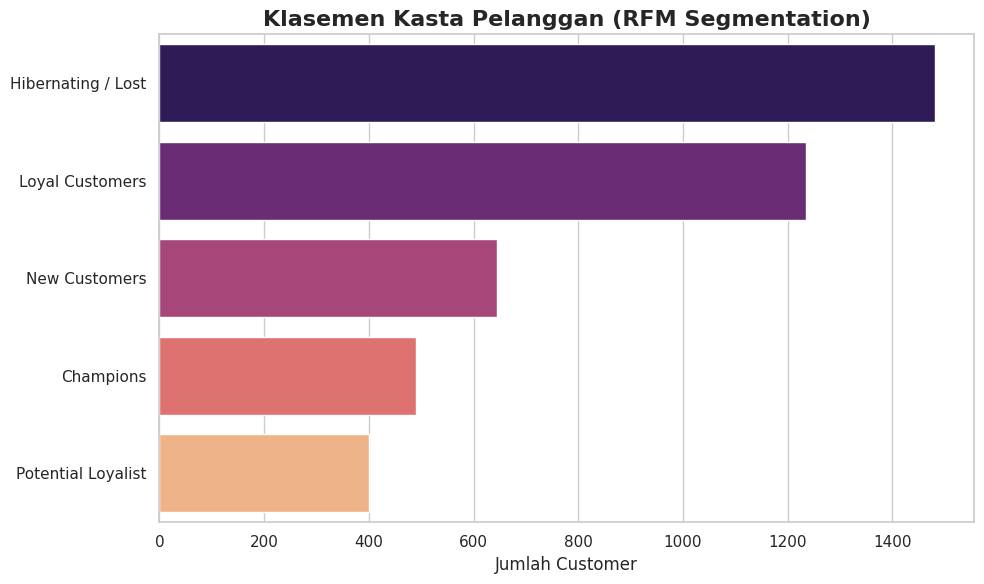

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(
    y='Customer_Profile',
    data=rfm,
    order=rfm['Customer_Profile'].value_counts().index,
    palette='magma'
)
plt.title('Klasemen Kasta Pelanggan (RFM Segmentation)', fontweight='bold', fontsize=16)
plt.xlabel('Jumlah Customer', fontsize=12)
plt.ylabel('', fontsize=12)
plt.tight_layout()
plt.show()

The segment bar chart provides the clearest summary of customer base health. Marketing budget allocation should be proportional to the value each segment generates — not distributed equally. Champions and Loyal Customers should receive the majority of retention investment, while the Hibernating/Lost segment requires a cost-effective win-back approach rather than full marketing spend.

### **8. Market Basket Analysis: Uncovering Product Co-Purchase Patterns**
Market Basket Analysis identifies which products are frequently purchased together within the same transaction. The insights derived directly inform product bundling strategy, cross-sell placement, and "frequently bought together" recommendations.

We apply the **FP-Growth algorithm** on UK transactions — which represent approximately 90% of the dataset — for two reasons:
1. **Computational efficiency:** FP-Growth uses a compressed prefix tree structure that is significantly faster than Apriori on large, sparse transaction matrices.
2. **Market focus:** Concentrating on UK transactions ensures association rules reflect the behavior of the dominant customer base, rather than being diluted by the varied purchasing patterns of smaller international markets.

**Filtering thresholds applied:**
- Minimum support: 2% (a product pair must appear in at least 2% of all baskets)
- Minimum lift: > 1.0 (the association must be stronger than random co-occurrence)

Rules are ranked by **lift** — the primary metric indicating the strength of a genuine purchasing relationship beyond what random chance would predict.

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# Why focus on UK transactions only?
# UK represents ~90% of all transactions in this dataset.
# Including all countries would dilute association rules because
# purchasing patterns in Germany or France may differ significantly
# from UK patterns — mixing them produces rules that are "average"
# across markets and not specifically actionable for any single market.
# The UK market is large enough to produce statistically reliable rules on its own.
uk_proportion = (df_product['Country'] == 'United Kingdom').mean()
print(f"UK proportion of df_product: {uk_proportion:.1%}")

df_uk = df_product[df_product['Country'] == 'United Kingdom'].copy()

# Why remove single-item baskets?
# Association rules require at least 2 products in a basket to define
# an antecedent → consequent relationship. Single-item transactions
# contribute to support counts but never to any rule.
# Removing them reduces memory usage without affecting rule quality.
invoice_item_count = df_uk.groupby('InvoiceNo')['Description'].nunique()
multi_item_invoices = invoice_item_count[invoice_item_count > 1].index
single_item_count = len(invoice_item_count) - len(multi_item_invoices)
print(f"\nTotal UK invoices: {len(invoice_item_count):,}")
print(f"Single-item invoices removed: {single_item_count:,} ({single_item_count/len(invoice_item_count):.1%})")
print(f"Multi-item invoices retained: {len(multi_item_invoices):,}")

df_uk = df_uk[df_uk['InvoiceNo'].isin(multi_item_invoices)]

# Pivot to basket format: rows = invoices, columns = products, values = 0/1
basket = df_uk.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"\nBasket matrix shape: {basket.shape}")
print(f"({basket.shape[0]:,} invoices × {basket.shape[1]:,} unique products)")

# Why FP-Growth instead of Apriori?
# With 500K+ transactions and thousands of unique products, Apriori must
# generate and test every possible candidate itemset — computationally
# prohibitive at this scale. FP-Growth builds a compressed prefix tree
# (FP-tree) that stores all transaction patterns in memory efficiently,
# avoiding candidate generation entirely. Runtime is typically 10-100×
# faster than Apriori on datasets of this size.

# Why min_support = 0.02?
# Support = proportion of all baskets containing this product pair.
# At 2%, a rule must appear in at least 2% of all UK baskets to be retained.
# Lower threshold = more rules but more noise; higher = fewer but more reliable.
# 2% is a practical starting point for a dataset of this size.
frequent_items = fpgrowth(basket, min_support=0.02, use_colnames=True)
print(f"\nFrequent itemsets found: {len(frequent_items):,}")

# Why filter by lift > 1?
# Lift measures how much more likely two products are purchased together
# compared to random chance. Lift = 1 means no association (independent).
# Lift < 1 means they are LESS likely to be bought together.
# Only lift > 1 rules are actionable for cross-sell recommendations.
rules_uk = association_rules(frequent_items, metric='lift', min_threshold=1.0)
rules_uk = rules_uk.sort_values('lift', ascending=False)
print(f"Association rules generated (lift > 1): {len(rules_uk):,}")
display(rules_uk.head(10))

Data kelar didietin! Sisa 454459 baris padat gizi. 🥩


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ukuran matriks: 15731 struk & 2789 barang. RAM AMAN JAYA! 🛡️
Lagi nyari jodoh pakai FP-Growth, tunggu bentar ya... ⏳


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


🔥 TOP 10 PASANGAN BARANG PALING BUCIN DI UK 🔥


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
193,(Wooden Star Christmas Scandinavian),(Wooden Heart Christmas Scandinavian),0.021168,0.744966,25.256610
192,(Wooden Heart Christmas Scandinavian),(Wooden Star Christmas Scandinavian),0.021168,0.717672,25.256610
202,(Small Dolly Mix Design Orange Bowl),(Small Marshmallows Pink Bowl),0.020596,0.653226,24.292896
203,(Small Marshmallows Pink Bowl),(Small Dolly Mix Design Orange Bowl),0.020596,0.765957,24.292896
215,(Pink Regency Teacup And Saucer),"(Roses Regency Teacup And Saucer, Green Regenc...",0.030322,0.698389,16.109039
210,"(Roses Regency Teacup And Saucer, Green Regenc...",(Pink Regency Teacup And Saucer),0.030322,0.699413,16.109039
211,"(Roses Regency Teacup And Saucer, Pink Regency...",(Green Regency Teacup And Saucer),0.030322,0.901701,15.485441
214,(Green Regency Teacup And Saucer),"(Roses Regency Teacup And Saucer, Pink Regency...",0.030322,0.520742,15.485441
212,"(Green Regency Teacup And Saucer, Pink Regency...",(Roses Regency Teacup And Saucer),0.030322,0.847247,14.315833
213,(Roses Regency Teacup And Saucer),"(Green Regency Teacup And Saucer, Pink Regency...",0.030322,0.512352,14.315833


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

The association rules table, sorted by **lift**, surfaces the strongest product co-purchase relationships in the UK market. A lift value greater than 1 confirms that the association is stronger than random chance — the higher the lift, the more reliable the pairing as a cross-sell or bundling recommendation.

**Reading the output:** An antecedent → consequent rule with high confidence means: "When a customer buys product A, they buy product B in X% of cases." High lift + high confidence = the most actionable pairing for product page recommendations, promotional bundles, or strategic shelf placement.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

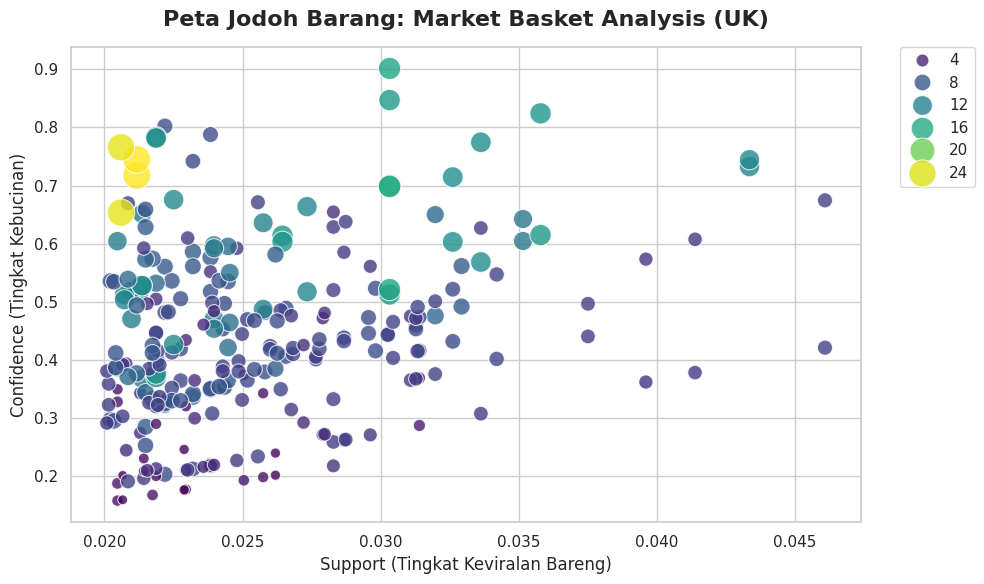

Plot berhasil digambar! Data juga udah diekspor ke CSV dan siap dibawa ke Tableau 🚀


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya grafik biar estetik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Bikin Scatter Plot dari data rules_uk
scatter = sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    sizes=(50, 400), # Ukuran titik (makin gede Lift, makin gede titiknya)
    palette='viridis', # Gradasi warna estetik
    alpha=0.8,
    data=rules_uk
)

# Nambahin judul dan label biar informatif
plt.title('Peta Jodoh Barang: Market Basket Analysis (UK)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Support (Tingkat Keviralan Bareng)', fontsize=12)
plt.ylabel('Confidence (Tingkat Kebucinan)', fontsize=12)

# Mengatur posisi legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

# ==========================================
# Tahap Ekspor Data buat dibawa ke Tableau
# ==========================================
# Pastikan data ini di-download dari Colab ya!
rules_uk.to_csv('market_basket_rules_uk.csv', index=False)
# df_rfm.to_csv('rfm_segmentation.csv', index=False) # Kalau RFM-nya juga mau dibawa
print("Plot berhasil digambar! Data juga udah diekspor ke CSV dan siap dibawa ke Tableau 🚀")

The scatter plot maps every association rule by support (x-axis) and confidence (y-axis), with bubble size representing lift. The most valuable rules occupy the **upper-right quadrant** — high support means they apply to a large share of transactions, while high confidence means they are reliable predictors of co-purchase behavior. Rules in the upper-left (high confidence, low support) represent niche but reliable pairings worth targeting for specific customer segments.

### **9. Time Series Analysis: When Does the Business Actually Run?**
Understanding *when* customers buy is as strategically important as understanding *what* and *how much* they buy. This section analyzes three temporal dimensions to surface operational and marketing implications:

1. **Monthly Revenue Trend:** Identifying seasonality and growth trajectory across the full 12-month period.
2. **Day-of-Week Patterns:** Revealing which days drive peak transaction volume — and which days see zero activity.
3. **Hourly Distribution:** Pinpointing the daily rush-hour window to inform campaign launch timing and staffing decisions.

In [ ]:
df_product

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour,Revenue
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,sale,2010-12,Wednesday,8,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,sale,2010-12,Wednesday,8,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,sale,2011-12,Friday,12,10.20
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France,sale,2011-12,Friday,12,12.60
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12,16.60
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12,16.60


In [ ]:
# Time Series Analysis uses df_master (not df_product) for accurate reporting.
#
# Why df_master and not df_product for revenue trends?
# df_product has been filtered to remove CustomerID Unknown, outliers,
# and non-sales transactions. This makes it suitable for product analysis
# and RFM, but it UNDER-REPORTS revenue because:
# - Transactions from anonymous customers (CustomerID Unknown) still
#   represent real revenue that should appear in financial reporting.
# - Removing them would make the monthly revenue trend appear lower
#   than the actual business performance.
#
# For operational patterns (orders by day/hour), we also use df_master
# filtered to Sales only — this captures all genuine purchase activity
# regardless of whether the customer was identified.

df_sales = df_master[df_master['transaction_type'] == 'sale'].copy()

if 'Revenue' not in df_sales.columns:
    df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']

# Monthly revenue trend
monthly_trend = df_sales.groupby('MonthYear')['Revenue'].sum().reset_index()
monthly_trend['MonthYear'] = monthly_trend['MonthYear'].astype(str)

# Orders by day of week (include Saturday to show zero-activity finding)
# Why include Saturday even though it has zero orders?
# Saturday = 0 transactions is one of the most operationally significant
# findings in this analysis. Hiding it by omission would obscure the insight.
daily_orders = df_sales.groupby('DayOfWeek')['InvoiceNo'].nunique().reset_index()

# Orders by hour
hourly_orders = df_sales.groupby('Hour')['InvoiceNo'].nunique().reset_index()

print(f"Sales transactions used for time series: {len(df_sales):,}")
print(f"Total revenue (all sales incl. anonymous): ${df_sales['Revenue'].sum():,.0f}")
print(f"\nMonthly breakdown:")
display(monthly_trend)

✨ TREN PENDAPATAN BULANAN ✨


,MonthYear,Total_Revenue
0,2010-12,576789.650
1,2011-01,419387.040
2,2011-02,358209.230
3,2011-03,490207.350
4,2011-04,386065.581
5,2011-05,519404.880
6,2011-06,469106.790
7,2011-07,475390.611
8,2011-08,484420.790
9,2011-09,694083.642



✨ TREN HARI TERSIBUK ✨


,Day,Total_Transactions
0,Monday,2957
1,Tuesday,3332
2,Wednesday,3459
3,Thursday,4017
4,Friday,2952
5,Sunday,2157


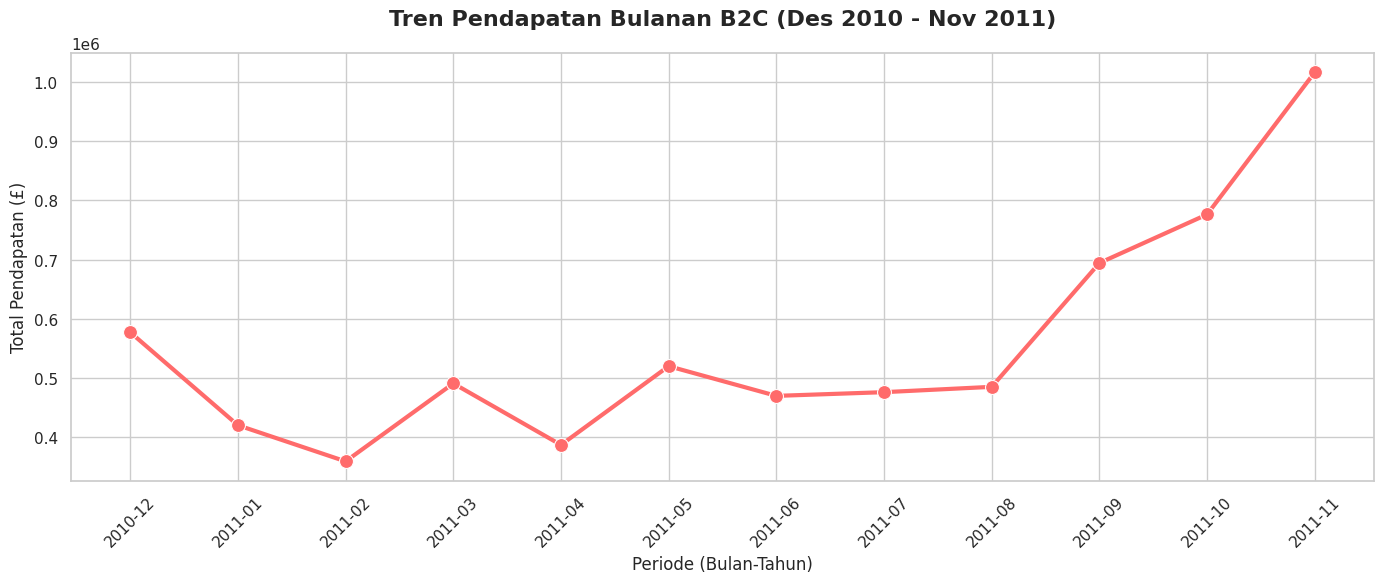

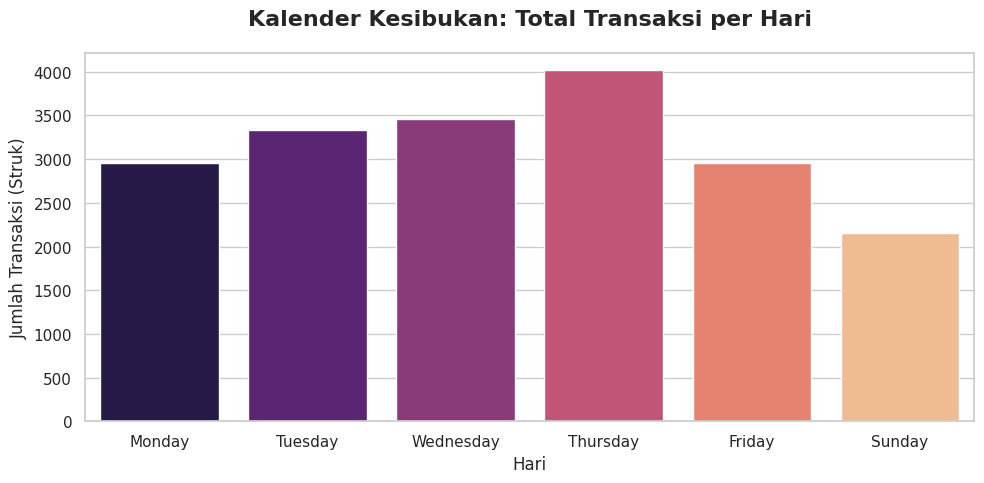

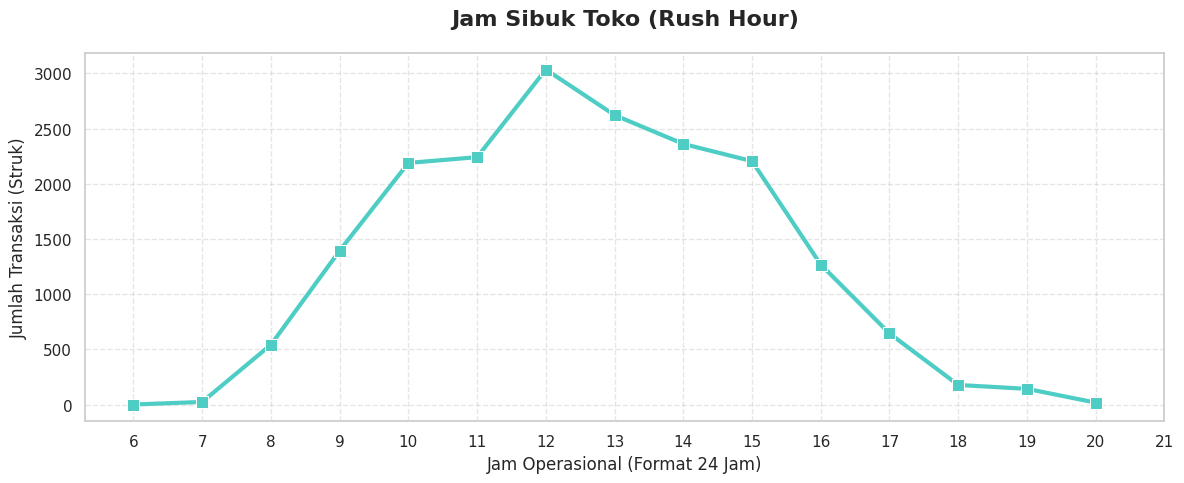

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema biar estetik paripurna ala Gen Z 💅
sns.set_theme(style="whitegrid", palette="pastel")

# ==========================================
# 1. GRAFIK TREN BULANAN (Rollercoaster Cuan)
# ==========================================
# Kita filter df monthly_trend, ambil semua data KECUALI '2011-12'
monthly_trend_clean = monthly_trend[monthly_trend['MonthYear'] != '2011-12']

# Sekarang, bikin grafiknya pake data yang udah difilter (monthly_trend_clean)
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend_clean, x='MonthYear', y='Total_Revenue',
             marker='o', markersize=10, color='#FF6B6B', linewidth=3)

# Bedah kosmetik grafiknya
plt.title('Tren Pendapatan Bulanan B2C (Des 2010 - Nov 2011)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Periode (Bulan-Tahun)', fontsize=12)
plt.ylabel('Total Pendapatan (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# 2. GRAFIK HARI TERSIBUK (Pola Mingguan)
# ==========================================
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_traffic, x='Day', y='Total_Transactions', palette='magma')

plt.title('Kalender Kesibukan: Total Transaksi per Hari', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Jumlah Transaksi (Struk)', fontsize=12)
plt.tight_layout()
plt.show()


# ==========================================
# 3. GRAFIK JAM SIBUK (Rush Hour)
# ==========================================
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_traffic, x='Hour', y='Total_Transactions',
             marker='s', markersize=8, color='#4ECDC4', linewidth=3)

plt.title('Jam Sibuk Toko (Rush Hour)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jam Operasional (Format 24 Jam)', fontsize=12)
plt.ylabel('Jumlah Transaksi (Struk)', fontsize=12)
plt.xticks(range(6, 22))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The three temporal charts surface three operationally significant findings:

1. **Monthly Revenue Trend:** Revenue shows consistent growth from January through November, with a sharp peak in **October–November** driven by pre-Christmas demand. December data is excluded as the period is incomplete and would misrepresent the full-month trend. Inventory replenishment should be planned **6 weeks ahead** of the November peak.

2. **Day-of-Week Patterns:** **Thursday** generates the highest transaction volume. Critically, **Saturday shows zero transactions** — the store is operationally inactive on that day. This is a meaningful operational constraint that should be confirmed with the operations team and factored into all campaign scheduling decisions.

3. **Peak Hours:** Transaction volume surges between **10 AM and 2 PM** and drops sharply after 3 PM. Flash sales, push notifications, and marketing campaign launches should be timed to this window — specifically **Thursday mornings** — to maximize customer reach.

In [ ]:
# ==========================================
# 🪄 MANTRA EXPORT: 3 RANTANG MENUJU TABLEAU
# ==========================================

# 1. Export Rantang Utama (Data Master Bersih)
# index=False biar kolom nomor urut dari Python nggak ikut ke-bawa dan menuh-menuhin data
df_product.to_csv('df_produk.csv', index=False)
print("✅ df_master_bersih.csv berhasil dibungkus!")

# 2. Export Rantang Mahkota (RFM)
# (Sesuaikan 'rfm_df' dengan nama variabel tabel RFM-mu ya)
rfm.to_csv('rfm_segmentation.csv', index=False)
print("✅ rfm_segmentation.csv berhasil dibungkus!")

# 3. Export Rantang Jodoh (Market Basket Rules)
# (Sesuaikan 'rules' dengan nama variabel tabel MBA-mu ya)
df_uk.to_csv('mba_rules.csv', index=False)
print("✅ mba_rules.csv berhasil dibungkus!")

print("\n🎉 SELAMAT! Tiga serangkai suci sudah siap dibawa ke pesta Tableau, Caca! 🚀")

✅ df_master_bersih.csv berhasil dibungkus!
✅ rfm_segmentation.csv berhasil dibungkus!
✅ mba_rules.csv berhasil dibungkus!

🎉 SELAMAT! Tiga serangkai suci sudah siap dibawa ke pesta Tableau, Caca! 🚀


### **Strategic Insights & Recommendations**

1. **Revenue Integrity First:** 12.7% of all records are non-revenue transactions (returns, damage, free items). Before any business decision is made from this data, the transaction classification layer established here must be applied — raw row counts are not reliable as a revenue proxy.

2. **Two Distinct Customer Segments Require Two Strategies:** The B2C (median 3 units) and B2B (outlier buyers at 80,000+ units) segments have fundamentally different needs. A single pricing, marketing, or inventory strategy will not serve both. Segment-specific approaches are essential.

3. **Focus Retention Budget on Champions and Loyal Customers:** These two segments generate a disproportionate share of revenue. Win-back campaigns for Hibernating/Lost customers should be low-cost — the ROI of heavy investment in lost customers rarely justifies the spend.

4. **Thursday 10AM–2PM Is the Business's Most Valuable Window:** All time-sensitive marketing activations (flash sales, campaigns, email sends) should be concentrated in this window for maximum customer reach.

5. **UK Market Is the Priority — But Netherlands and EIRE Signal Expansion Potential:** At 90% of revenue, UK deserves the most operational focus. However, Netherlands and EIRE show disproportionately high revenue relative to their transaction count — indicating higher average order values and warranting targeted expansion consideration.

In [ ]:
df_product

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,transaction_type,MonthYear,DayOfWeek,Hour,Revenue,Total_Revenue
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,sale,2010-12,Wednesday,8,15.30,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,sale,2010-12,Wednesday,8,22.00,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,sale,2010-12,Wednesday,8,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,sale,2011-12,Friday,12,10.20,10.20
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France,sale,2011-12,Friday,12,12.60,12.60
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12,16.60,16.60
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France,sale,2011-12,Friday,12,16.60,16.60
